In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/YouTube/bin/python


In [2]:
import sys
print(sys.version)


3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:31:09) [GCC 11.2.0]


# Projeto 13: Rede Neural Convolucional MNIST Aumento de Imagens

Ideal para quem tem poucas imagens, como 100 de gatos e 5 de cachorros. 

O que pode acontecer é a rede neural não se adaptar.

poucas imagens 
,

mas podemos alterar no pytorch, fazendo transformações para deixar 200 imagens de gatos e cães.

Girar a imagem na horizontal, na vertical, dar um zoom.

## Etapa 1: Importação das bibliotecas

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchvision import datasets
import torchvision.transforms as transforms
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

In [4]:
torch.manual_seed(123) # sempre carregar o mesmo valor

In [9]:
# base de treino, pois aumentaremos a base de dados de treinamento.
# Compose: Cria um pipeline (uma lista) de transformações que serão aplicadas em sequência
transform_train = transforms.Compose([
    
    # 1. Flip: Inverte a imagem horizontalmente de forma aleatória (espelhamento)
    transforms.RandomHorizontalFlip(),
    
    # 2. Affine: Aplica distorções geométricas aleatórias:
    transforms.RandomAffine(
        degrees = 7,         # Rotação: Gira a imagem em até 7 graus
        # horizontal and vertical shifts, translação.
        translate = (0, 0.07), # Deslocamento: Move a imagem levemente (7%) para os lados/cima/baixo
        shear = 7,           # Cisalhamento: Inclina a imagem (deixa "de lado") -> cortes nas imagens
        # zoom range
        scale = (1, 1.2)     # Zoom: Dá um zoom aleatório de 0% a 20% # (zoom original =1, zoom alterado =1.2)
    ),
    
    # 3. ToTensor: Converte a imagem (PIL) para o formato de Tensor do PyTorch 
    # e coloca os pixels na escala de 0 a 1 (normalização básica).
    transforms.ToTensor()
])

In [10]:
transform_test = transforms.ToTensor() #carrega a imagem em si, apenas o de teste

In [19]:
# download e transformação

In [11]:
train = datasets.MNIST(root = '.', train = True, download = True, transform = transform_train)
test = datasets.MNIST(root = '.', train = False, download = True, transform = transform_test)

# verificando


In [13]:

# Mostra o local dos arquivos, número de imagens e as transformações aplicadas
print(train)

# Ver as classes (0 a 9)
print(train.classes)

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
               RandomHorizontalFlip(p=0.5)
               RandomAffine(degrees=[-7.0, 7.0], translate=(0, 0.07), scale=(1, 1.2), shear=[-7.0, 7.0])
               ToTensor()
           )
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [14]:
# Pega a primeira imagem e o gabarito (label) dela
imagem, rotulo = train[0]

print(f"Formato do Tensor: {imagem.shape}") # Ex: [1, 28, 28]
print(f"Classe (Target): {rotulo}")        # Ex: 5

Formato do Tensor: torch.Size([1, 28, 28])
Classe (Target): 5


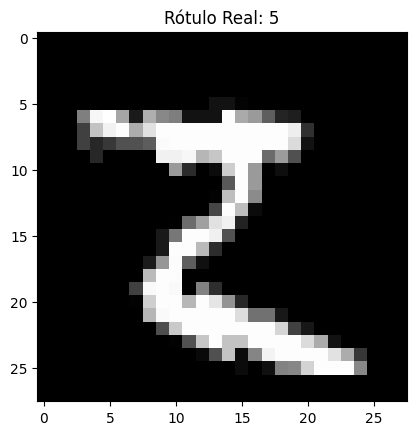

In [15]:
import matplotlib.pyplot as plt

# Pegamos a imagem 0
imagem, rotulo = train[0]

# .squeeze() remove a dimensão de canal [1, 28, 28] -> [28, 28]
plt.imshow(imagem.squeeze(), cmap='gray')
plt.title(f'Rótulo Real: {rotulo}')
plt.show()

In [16]:
# Ver os pixels da primeira imagem de forma bruta
print(train.data[0]) 

# Ver os primeiros 10 rótulos do dataset
print(train.targets[:10])

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

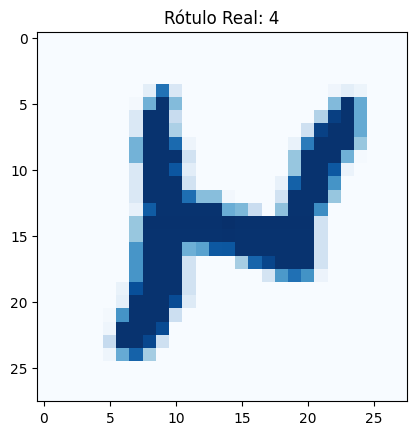

In [17]:
import matplotlib.pyplot as plt

# Pegamos a imagem 0
imagem, rotulo = train[20]

# .squeeze() remove a dimensão de canal [1, 28, 28] -> [28, 28]
plt.imshow(imagem.squeeze(), cmap='Blues')
plt.title(f'Rótulo Real: {rotulo}')
plt.show()

In [21]:
# train.data -> Matriz com os pixels (60000, 28, 28)
# train.targets -> Vetor com as respostas (0 a 9)
# train.classes -> Lista com o nome das categorias
# train[i] -> Retorna (imagem_processada, classe) do índice i

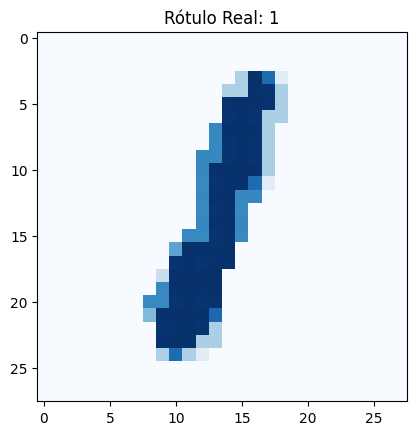

In [18]:
import matplotlib.pyplot as plt

# Pegamos a imagem 0
imagem, rotulo = train[200]

# .squeeze() remove a dimensão de canal [1, 28, 28] -> [28, 28]
plt.imshow(imagem.squeeze(), cmap='Blues')
plt.title(f'Rótulo Real: {rotulo}')
plt.show()

## Transformar para o Pytorch

DataLoader é o "garçom" da sua rede neural. Pega o conjunto de dados bruto (train ou test) e o organiza para que a rede consiga consumi-lo de forma eficiente.

Sem o DataLoader, teria que carregar imagem por imagem manualmente. Com ele, se automatiza todo o processo de alimentação da rede.

In [22]:
# O DataLoader gerencia a entrega dos dados para a rede neural
train_loader = torch.utils.data.DataLoader(
    train,            # O dataset (MNIST) que você carregou
    batch_size = 128, # Define que a rede verá 128 imagens de uma só vez (um lote)
   # shuffle = True    # Geralmente adicionamos isso no treino para embaralhar os números
)

test_loader = torch.utils.data.DataLoader(
    test,             # O dataset de validação
    batch_size = 128  # Também processa 128 por vez para ser mais rápido
)

## Etapa 3: Construção do modelo

Exemplo de rede neural mais simples;

CNN - Convolutional Neural Network). Serve para extrair padrões espaciais da imagem e classificá-los em uma das 10 categorias (como os números de 0 a 9).

In [34]:
class classificador(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. CAMADA DE CONVOLUÇÃO: Aplica 32 filtros (3x3) para achar bordas e formas. 
        # Entrada: 1 canal (cinza). Saída: 32 mapas de características.
        self.conv = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = (3, 3))
        
        # 2. ATIVAÇÃO ReLU: Torna a rede inteligente, removendo valores negativos (zera pixels inúteis).
        self.activation = nn.ReLU()
        # ReLU (Rectified Linear Unit): Função que zera valores negativos e mantém positivos.
        # Serve para introduzir não-linearidade, permitindo que a rede aprenda padrões complexos.
        # Evita que o treinamento trave e torna o processo muito mais rápido.
        
        # 3. POOLING: Reduz o tamanho da imagem pela metade (28x28 vira 14x14, etc), pegando só o pixel mais forte.
        self.pool = nn.MaxPool2d(kernel_size = (2, 2))
        
        # 4. FLATTEN: Estica a matriz de pixels em uma linha só (vetor), para entrar na rede densa.
        self.flatten = nn.Flatten()
        
        # 5. CAMADA LINEAR (DENSA): 32 filtros * 13*13 pixels = 5408 entradas que levam a 128 neurônios.
        self.linear = nn.Linear(in_features = 32*13*13, out_features = 128)

       
        # 6. SAÍDA: Transforma os 128 neurônios ocultos nas 10 classes finais.
        self.output = nn.Linear(128, 10)

    def forward(self, X):
        # O fluxo de dados: Convolução -> Ativação -> Pooling
        X = self.pool(self.activation(self.conv(X)))
        
        # Transforma para vetor 1D
        X = self.flatten(X)
        
        # Processa na rede mais densa com ativação
        X = self.activation(self.linear(X))
        
        # Gera o resultado final (logits)
        X = self.output(X)

        return X

Cálculo do Flatten ($32 \times 13 \times 13$): * Se sua imagem começa com 28x28:

Após a convolução (3x3), ela cai para 26x26.

Após o Pooling (2x2), ela cai exatamente para 13x13.

Por isso o in_features da camada linear precisa ser $32 \times 13 \times 13 = 5408$.


#### ++++++++++++++++++++++++++++++++++++++++++++++++


O kernel_size = (3, 3) define o tamanho da "janela" (ou filtro) que a rede neural vai usar para escanear a sua imagem.

1) Deslizamento: O kernel de $3 \times 3$ (um quadradinho de 9 pixels no total) começa no canto superior esquerdo da imagem.

2) Cálculo: Ele multiplica os valores dos pixels da imagem pelos "pesos" que a rede está aprendendo.

3) Extração: O resultado dessa conta gera um único novo pixel, que representa uma característica (uma borda, um brilho, uma curva).

4) Movimento: Ele desliza por toda a imagem, pixel por pixel, até criar um novo "mapa de características".


Quando você usa um kernel de $(3, 3)$, a imagem "encolhe" um pouquinho nas bordas.

Se a imagem é 28x28 e você passa esse filtro, o resultado será 26x26.

Isso acontece porque o centro do filtro não consegue chegar nos pixels das extremidades sem que a "lupa" saia para fora da foto.

In [29]:
28-3 +1

26

In [31]:
26/2

13.0

In [32]:
32*13*13


5408

A ReLU (abreviação de Rectified Linear Unit) é a Função de Ativação mais usada no mundo das redes neurais hoje em dia.Pense nela como um "interruptor inteligente" que decide quais informações devem passar para a próxima camada da rede e quais devem ser descartadas.

🛠️ Como ela funciona (A regra é simples)A lógica matemática da ReLU é:Se o valor for negativo, ela transforma em 0 (desliga o neurônio).Se o valor for positivo, ela mantém o valor exatamente como ele é.Matematicamente: $$f(x) = \max(0, x)$$

🔍 Por que usar a ReLU no código? Elimina o ruído: Ao zerar valores negativos, ela ajuda a rede a focar apenas nos sinais importantes que ela detectou na imagem.Velocidade: Diferente de outras funções (como Sigmoid ou Tanh), a ReLU é computacionalmente muito barata. É muito mais rápido para o processador calcular um "máximo entre 0 e X" do que fazer contas complexas de exponenciação.Evita o sumiço do gradiente: Em redes profundas, as funções antigas faziam o aprendizado ficar muito lento ou parar. A ReLU mantém o sinal forte, permitindo que a rede aprenda muito mais rápido.

In [37]:
net = classificador()            # 1. Cria a rede (o cérebro)
criterion = nn.CrossEntropyLoss() # 2. Define como medir o erro (a prova)
optimizer = optim.Adam(net.parameters()) # 3. Define quem ajusta os pesos (o professor)

1. net = classificador()
O Objeto do Modelo

O que faz: Cria uma "instância" (uma cópia viva) da arquitetura que se desenhou na classe classificador.

Na prática: É aqui que o computador reserva espaço na memória e cria os pesos (weights) e vieses (bias) iniciais (que começam aleatórios). Agora net é o seu cérebro artificial pronto para ser treinado.

2. criterion = nn.CrossEntropyLoss()
A Régua do Erro (Função de Perda)

O que faz: Define a fórmula matemática para medir o quão ruim a rede está indo.

Na prática: Para classificação (como o MNIST), a CrossEntropy é o padrão. Ela compara a previsão da rede com a resposta real. Se a rede estiver muito confiante no número errado, o criterion gera um valor de "perda" (loss) alto. O objetivo do treino é diminuir esse número.

3. optimizer = optim.Adam(net.parameters())
O Mecanismo de Ajuste (Otimizador)

O que faz: É o algoritmo que realmente altera os pesos da rede para diminuir o erro.

net.parameters(): Está dizendo ao Adam: "Ei, estes são os pesos que você tem permissão para mexer".

Adam: É um dos melhores otimizadores porque ele é "adaptativo". Ele ajusta a velocidade do aprendizado (Learning Rate) sozinho durante o treino, o que o torna muito mais rápido que o clássico SGD (Gradiente Descendente Estocástico).

In [41]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [43]:
device

device(type='cpu')

In [44]:
net.to(device)

classificador(
  (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (activation): ReLU()
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=5408, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
)

## Etapa 4: Treinamento do modelo

In [46]:
# Função principal que processa os dados e treina a rede por uma época
def training_loop(loader, epoch):

    # Inicializa acumuladores para calcular a média de erro e acerto ao fim da época
    running_loss = 0.
    running_accuracy = 0.

    # Itera sobre os lotes (batches) de imagens do DataLoader
    for i, data in enumerate(loader):
        # 1. Carrega os dados e envia para o hardware configurado (GPU ou CPU)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # 2. Zera os gradientes acumulados para evitar que o erro anterior interfira no atual
        optimizer.zero_grad()

        # 3. FORWARD: Passa as imagens pela rede para obter as previsões
        outputs = net(inputs)

        # 4. LOSS: Calcula a distância entre o que a rede chutou e o resultado real
        loss = criterion(outputs, labels)
        
        # 5. BACKWARD: O PyTorch calcula "quem" deve ser ajustado para diminuir o erro
        loss.backward()

        # 6. STEP: O otimizador (Adam) efetivamente altera os pesos da rede
        optimizer.step()

        # Acumula o valor do erro bruto para a média final
        running_loss += loss.item()

        # --- CÁLCULO DA ACURÁCIA NO LOTE ---
        # Converte a saída em probabilidades (0 a 1)
        ps = F.softmax(outputs)
        # Pega a classe com maior probabilidade
        top_p, top_class = ps.topk(k = 1, dim = 1)
        # Verifica se a classe prevista é igual ao rótulo real (Gera True/False)
        equals = top_class == labels.view(*top_class.shape)
        # Transforma True/False em 1/0 e tira a média do lote
        accuracy = torch.mean(equals.type(torch.float))

        # Acumula a acurácia para a média final da época
        running_accuracy += accuracy

        # Imprimindo os dados referentes a este loop
        # Imprime o progresso em tempo real na mesma linha
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, i + 1, len(loader), loss, accuracy), end = '\r')
    
    
    # Imprimindo os dados referentes a esta época
    # EXIBIÇÃO FINAL: Mostra o erro e a precisão média de toda a época
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch+1, running_loss/len(loader), running_accuracy/len(loader)))

treinamento por 5 épocas

In [47]:
for epoch in range(5):
    print('Treinando...')
    training_loop(train_loader, epoch)

    net.eval()
    print('Validando...')
    training_loop(test_loader, epoch)

    net.train()

Treinando...


/tmp/ipykernel_24848/2466914808.py:34: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  ps = F.softmax(outputs)


ÉPOCA   1 FINALIZADA: perda 0.60952 - precisão 0.804720
Validando...
ÉPOCA   1 FINALIZADA: perda 0.17067 - precisão 0.948770
Treinando...
ÉPOCA   2 FINALIZADA: perda 0.26026 - precisão 0.918947
Validando...
ÉPOCA   2 FINALIZADA: perda 0.10449 - precisão 0.967760
Treinando...
ÉPOCA   3 FINALIZADA: perda 0.18833 - precisão 0.941007
Validando...
ÉPOCA   3 FINALIZADA: perda 0.07276 - precisão 0.977550
Treinando...
ÉPOCA   4 FINALIZADA: perda 0.15539 - precisão 0.952479
Validando...
ÉPOCA   4 FINALIZADA: perda 0.05400 - precisão 0.984870
Treinando...
ÉPOCA   5 FINALIZADA: perda 0.13588 - precisão 0.958367
Validando...
ÉPOCA   5 FINALIZADA: perda 0.04272 - precisão 0.987540


In [49]:
# rede neural convolucional menor, uma camada conv e uma de pooling

In [50]:
# resultado bom com poucas imagens

acurácia ou precisão de mais de 0,9

ou sejá, acurácia boa ÉPOCA   5 FINALIZADA: perda 0.04272 - precisão 0.987540
